# LOAN PREDICTION MODEL

# Importing the important libraries

In [1]:
# Required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')


# Feature Enginnering

In [2]:
# Load data (replace this path with your own if using a file)
df = pd.read_csv("loan_data.csv")  # Adjust filename if needed


In [3]:
# Basic cleanup
df = df.dropna()  # Drop rows with missing values

In [4]:
# Fix 'Dependents' column: convert '3+' to integer 3
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

# Encode categorical variables
label_encoders = {}
categorical_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


In [5]:
# Feature-target split
X = df.drop(columns=['Loan_ID', 'Loan_Status'])
y = df['Loan_Status']

# Model Building

In [6]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Model 1: Random Forest (Bagging)
# ===========================
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [8]:
print("Random Forest Results")
print(confusion_matrix(y_test, rf_preds))
print(classification_report(y_test, rf_preds))
print("Accuracy:", accuracy_score(y_test, rf_preds))

Random Forest Results
[[11  9]
 [ 3 39]]
              precision    recall  f1-score   support

           0       0.79      0.55      0.65        20
           1       0.81      0.93      0.87        42

    accuracy                           0.81        62
   macro avg       0.80      0.74      0.76        62
weighted avg       0.80      0.81      0.80        62

Accuracy: 0.8064516129032258


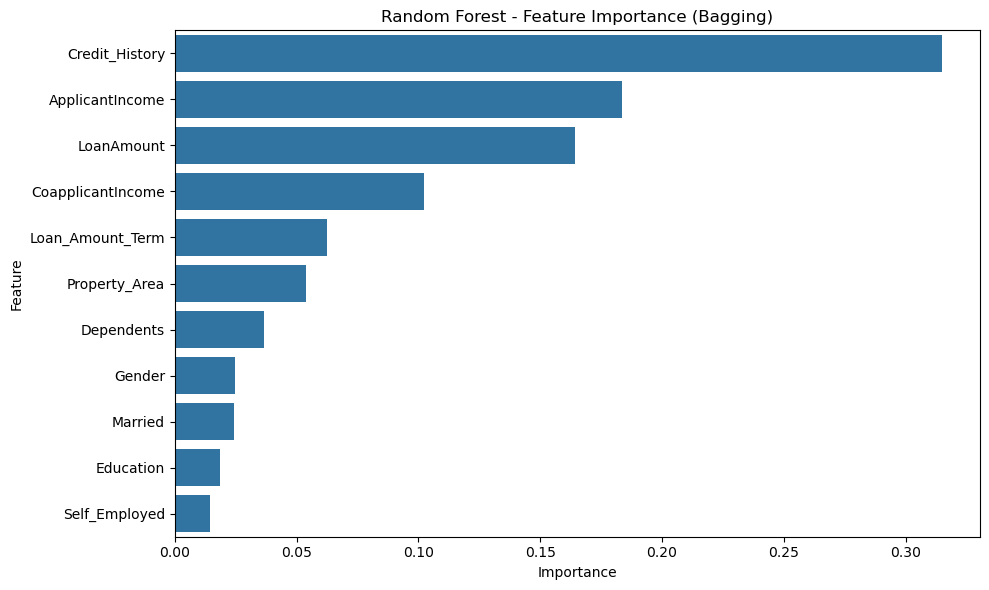

In [9]:
# Plot feature importance - Random Forest
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importance)
plt.title("Random Forest - Feature Importance (Bagging)")
plt.tight_layout()
plt.show()


In [10]:
# Model 2: XGBoost (Boosting)
# ===========================
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
print("XGBoost Results")
print(confusion_matrix(y_test, xgb_preds))
print(classification_report(y_test, xgb_preds))
print("Accuracy:", accuracy_score(y_test, xgb_preds))


XGBoost Results
[[12  8]
 [ 5 37]]
              precision    recall  f1-score   support

           0       0.71      0.60      0.65        20
           1       0.82      0.88      0.85        42

    accuracy                           0.79        62
   macro avg       0.76      0.74      0.75        62
weighted avg       0.78      0.79      0.79        62

Accuracy: 0.7903225806451613


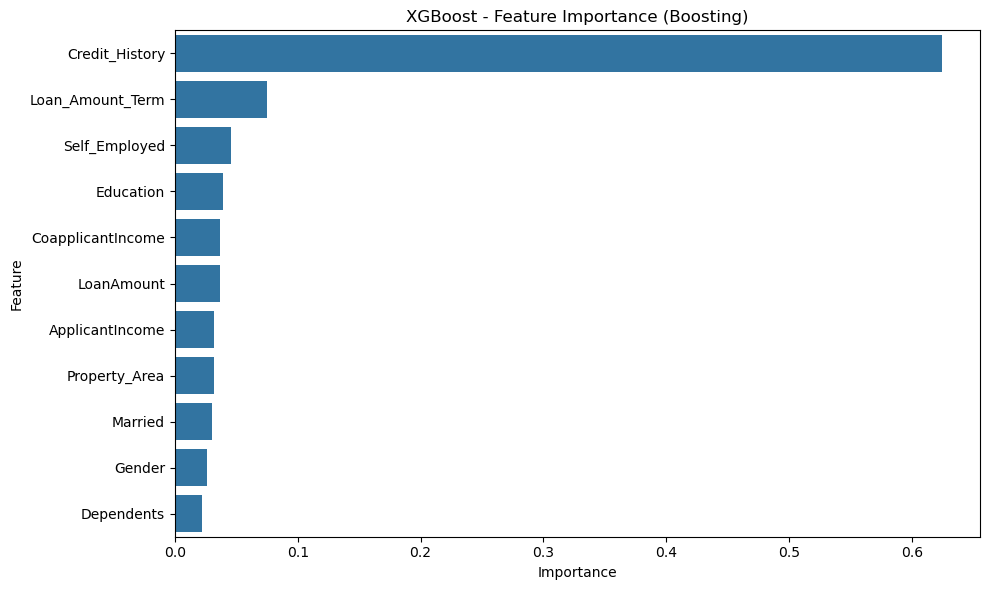

In [11]:
# Plot feature importance - XGBoost
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=xgb_importance)
plt.title("XGBoost - Feature Importance (Boosting)")
plt.tight_layout()
plt.show()